# 06 - Baseline Training

CitrusNet trained from scratch on the 224x224 processed set. No pretrained weights.
Test set is not loaded anywhere in this notebook.

In [1]:
import os
import json

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

from citrus_common import load_normalization_stats, get_transforms, CitrusLeafDataset
from citrus_model import CitrusNet, init_weights

## Training loop module

Pulled out into `citrus_train.py` so it can be reused for the ablation notebooks later.

In [2]:
%%writefile citrus_train.py
import random

import numpy as np
import torch


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def fit(model, train_loader, val_loader, criterion, optimizer, device,
        max_epochs=100, early_stop_patience=10, scheduler=None,
        checkpoint_path=None, verbose=True):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # ReduceLROnPlateau needs the metric it's watching
        if scheduler is not None:
            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        if verbose:
            print(
                f"epoch {epoch:3d}  train_loss {train_loss:.4f}  train_acc {train_acc:.4f}  "
                f"val_loss {val_loss:.4f}  val_acc {val_acc:.4f}  lr {current_lr:.2e}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            if checkpoint_path is not None:
                torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                if verbose:
                    print(f"no val_loss improvement for {early_stop_patience} epochs, stopping early at epoch {epoch}")
                break

    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_val_loss
    return history


Overwriting citrus_train.py


In [3]:
import citrus_train as ct

## Seed and device

In [4]:
ct.set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(device)

cuda


## Data

Train uses the augmented transform, val does not.

In [5]:
mean, std = load_normalization_stats("normalization_stats.json")

train_transform = get_transforms(augment=True, mean=mean, std=std, size=224)
val_transform = get_transforms(augment=False, mean=mean, std=std, size=224)

train_dataset = CitrusLeafDataset(root_dir="processed/224", split="train", transform=train_transform)
val_dataset = CitrusLeafDataset(root_dir="processed/224", split="val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

len(train_dataset), len(val_dataset)

(1131, 242)

## Model

Same CitrusNet as the architecture notebook, He/Glorot init applied fresh for this run.

In [6]:
model = CitrusNet(num_classes=4)
init_weights(model)
model = model.to(device)

## Loss, optimizer, scheduler

Class weights are inverse-frequency, in class_to_idx order (aphids, gummosis, healthy, leaf_minnor).

In [7]:
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

## Train

In [8]:
os.makedirs("checkpoints", exist_ok=True)
checkpoint_path = "checkpoints/baseline_best.pt"

history = ct.fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    max_epochs=100,
    early_stop_patience=10,
    scheduler=scheduler,
    checkpoint_path=checkpoint_path,
    verbose=True,
)

epoch   1  train_loss 0.8136  train_acc 0.6631  val_loss 0.4025  val_acc 0.8388  lr 1.00e-03
epoch   2  train_loss 0.4327  train_acc 0.8435  val_loss 0.5093  val_acc 0.8017  lr 1.00e-03
epoch   3  train_loss 0.3516  train_acc 0.8718  val_loss 0.1876  val_acc 0.9091  lr 1.00e-03
epoch   4  train_loss 0.2585  train_acc 0.9240  val_loss 0.0691  val_acc 0.9917  lr 1.00e-03
epoch   5  train_loss 0.2295  train_acc 0.9240  val_loss 0.1645  val_acc 0.9504  lr 1.00e-03
epoch   6  train_loss 0.2087  train_acc 0.9248  val_loss 0.0898  val_acc 0.9793  lr 1.00e-03
epoch   7  train_loss 0.2301  train_acc 0.9222  val_loss 0.1410  val_acc 0.9504  lr 1.00e-03
epoch   8  train_loss 0.1533  train_acc 0.9531  val_loss 0.0299  val_acc 0.9959  lr 1.00e-03
epoch   9  train_loss 0.1558  train_acc 0.9549  val_loss 0.0339  val_acc 0.9876  lr 1.00e-03
epoch  10  train_loss 0.1319  train_acc 0.9646  val_loss 0.0280  val_acc 0.9917  lr 1.00e-03
epoch  11  train_loss 0.1409  train_acc 0.9567  val_loss 0.0406  val_a

In [9]:
epochs_run = len(history["train_loss"])
print(f"best epoch: {history['best_epoch']}")
print(f"best val_loss: {history['best_val_loss']:.4f}")
print(f"val_acc at best epoch: {history['val_acc'][history['best_epoch'] - 1]:.4f}")
print(f"epochs run: {epochs_run} / 100")

best epoch: 30
best val_loss: 0.0010
val_acc at best epoch: 1.0000
epochs run: 40 / 100


## Save history

In [10]:
history_df = pd.DataFrame({
    "epoch": range(1, epochs_run + 1),
    "train_loss": history["train_loss"],
    "train_acc": history["train_acc"],
    "val_loss": history["val_loss"],
    "val_acc": history["val_acc"],
    "lr": history["lr"],
})
history_df.to_csv("history_baseline.csv", index=False)
history_df.tail()

,epoch,train_loss,train_acc,val_loss,val_acc,lr
35,36,0.034279,0.987622,0.001464,1.0,0.000250
36,37,0.020948,0.997347,0.001037,1.0,0.000250
37,38,0.032851,0.992042,0.001129,1.0,0.000125
38,39,0.021557,0.997347,0.001455,1.0,0.000125
39,40,0.018459,0.993811,0.001163,1.0,0.000125


## Curves

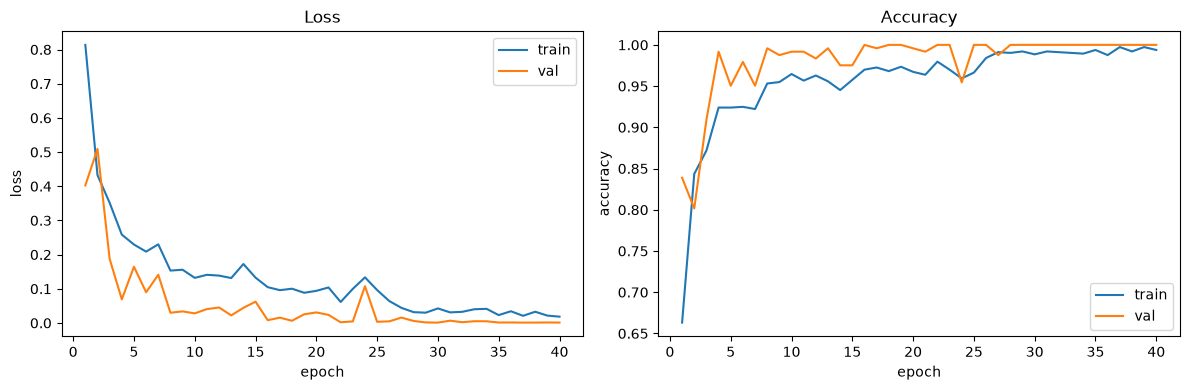

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

In [12]:
print("Baseline training summary")
print(f"  epochs run:      {epochs_run} / 100")
print(f"  best epoch:      {history['best_epoch']}")
print(f"  best val_loss:   {history['best_val_loss']:.4f}")
print(f"  best val_acc:    {history['val_acc'][history['best_epoch'] - 1]:.4f}")
print(f"  final lr:        {history['lr'][-1]:.2e}")
print(f"  checkpoint:      {checkpoint_path}")

Baseline training summary
  epochs run:      40 / 100
  best epoch:      30
  best val_loss:   0.0010
  best val_acc:    1.0000
  final lr:        1.25e-04
  checkpoint:      checkpoints/baseline_best.pt
